Name : Nisha Yuvraj Pragane | DIV:SEDA | Roll no :13 | PRN : 1252090013 | BATCH :B1

Assignment 6 : Use the diabetes data set from UCI and Pima Indians Diabetes data set for performing the
following: a. Univariate analysis: Frequency, Mean, Median, Mode, Variance, Standard
Deviation, Skewness and Kurtosis b. Bivariate analysis: Linear and logistic regression
modeling c. Multiple Regression analysis d. Also compare the results of the above analysis
for the two data sets. Dataset link: https://www.kaggle.com/datasets/uciml/pima-indiansdiabetes-database

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, mean_squared_error, r2_score, confusion_matrix

In [ ]:
pima = pd.read_csv("diabetes.csv")

print("Pima Dataset Shape:", pima.shape)
print(pima.head())

Pima Dataset Shape: (768, 9)
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [ ]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()
sklearn_df = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
sklearn_df['target'] = diabetes.target

print("Sklearn diabetes Shape :", sklearn_df.shape)
print(sklearn_df.head())

Sklearn diabetes Shape : (442, 11)
        age       sex       bmi        bp        s1        s2        s3  \
0  0.038076  0.050680  0.061696  0.021872 -0.044223 -0.034821 -0.043401   
1 -0.001882 -0.044642 -0.051474 -0.026328 -0.008449 -0.019163  0.074412   
2  0.085299  0.050680  0.044451 -0.005670 -0.045599 -0.034194 -0.032356   
3 -0.089063 -0.044642 -0.011595 -0.036656  0.012191  0.024991 -0.036038   
4  0.005383 -0.044642 -0.036385  0.021872  0.003935  0.015596  0.008142   

         s4        s5        s6  target  
0 -0.002592  0.019907 -0.017646   151.0  
1 -0.039493 -0.068332 -0.092204    75.0  
2 -0.002592  0.002861 -0.025930   141.0  
3  0.034309  0.022688 -0.009362   206.0  
4 -0.002592 -0.031988 -0.046641   135.0  


Univariate analysis: Frequency,Mean, Median, Mode, Variance, Standard Deviation, Skewness and Kurtosis

In [ ]:
def univariate_analysis(df):
  result=pd.DataFrame({
      "Mean":df.mean(),
      "Median":df.median(),
      "Mode":df.mode().iloc[0],
      "Variance":df.var(),
      "Standard Deviation":df.std(),
      "Skewness":df.skew(),
      "Kurtosis":df.kurtosis()
  })
  return result

In [ ]:
print("univariate analysis of pima dataset")
print(univariate_analysis(pima))

print("univariate analysis of sklearn diabetes dataset")
print(univariate_analysis(sklearn_df))

univariate analysis of pima dataset
                                Mean    Median    Mode      Variance  \
Pregnancies                 3.845052    3.0000   1.000     11.354056   
Glucose                   120.894531  117.0000  99.000   1022.248314   
BloodPressure              69.105469   72.0000  70.000    374.647271   
SkinThickness              20.536458   23.0000   0.000    254.473245   
Insulin                    79.799479   30.5000   0.000  13281.180078   
BMI                        31.992578   32.0000  32.000     62.159984   
DiabetesPedigreeFunction    0.471876    0.3725   0.254      0.109779   
Age                        33.240885   29.0000  22.000    138.303046   
Outcome                     0.348958    0.0000   0.000      0.227483   

                          Standard Deviation  Skewness  Kurtosis  
Pregnancies                         3.369578  0.901674  0.159220  
Glucose                            31.972618  0.173754  0.640780  
BloodPressure                      19.3558

In [ ]:
import matplotlib.pyplot as plt
def scatter_skew_kurtosis(df, title):
    skewness = df.skew(numeric_only=True)
    kurtosis = df.kurtosis(numeric_only=True)
    features = skewness.index
    plt.figure(figsize=(14,6))
    plt.scatter(features, skewness, marker='o', label='Skewness')
    plt.scatter(features, kurtosis, marker='x', label='Kurtosis')
    plt.xticks(rotation=60)
    plt.axhline(0)
    plt.title(f"Skewness vs Kurtosis - {title}")
    plt.xlabel("Features")
    plt.ylabel("Value")
    plt.legend()
    plt.tight_layout()
    plt.show()

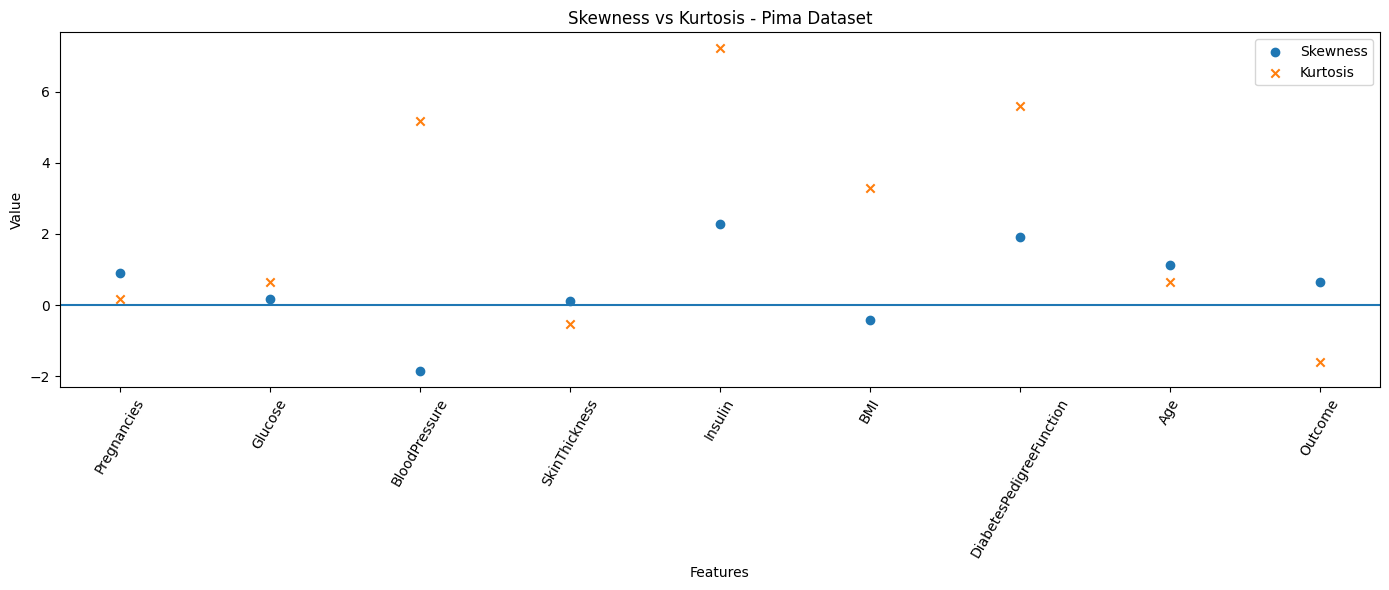

In [ ]:
scatter_skew_kurtosis(pima, "Pima Dataset")

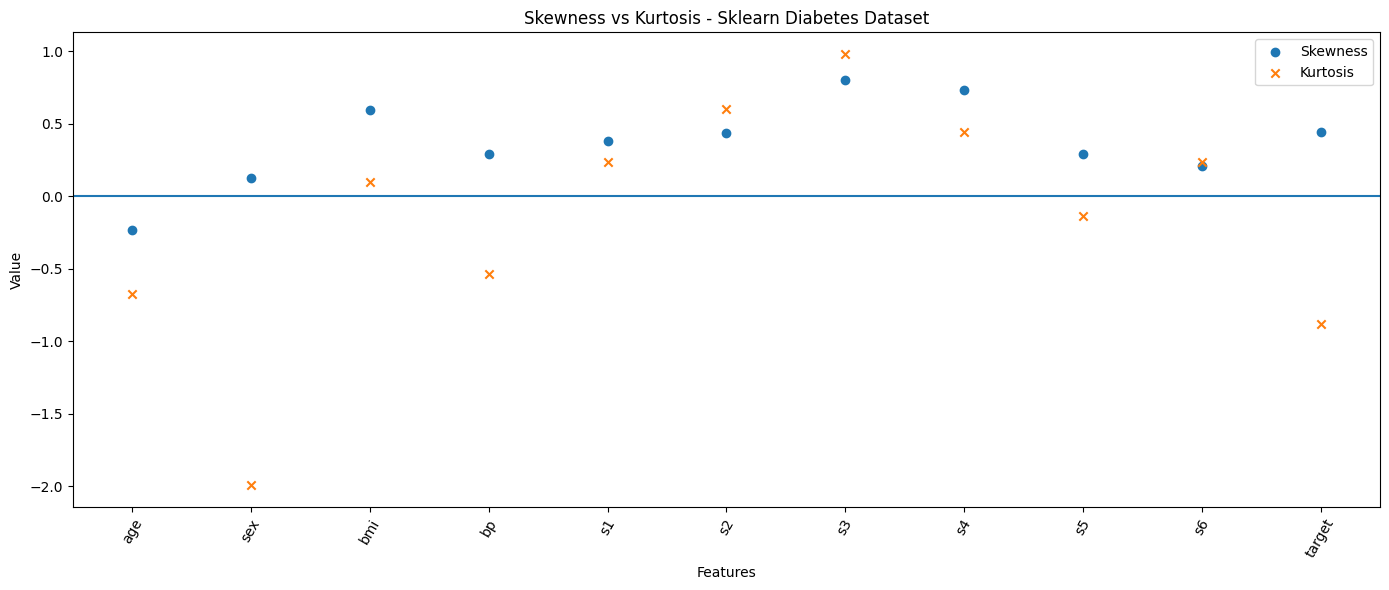

In [ ]:
scatter_skew_kurtosis(sklearn_df, "Sklearn Diabetes Dataset")

Frequency Distribution

In [ ]:
print("Frequency of Outcome in Pima Dataset")
print(pima["Outcome"].value_counts())

Frequency of Outcome in Pima Dataset
Outcome
0    500
1    268
Name: count, dtype: int64


Bivariate analysis:Linear Regression

In [ ]:
X = sklearn_df[['bmi']]
y = sklearn_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
lin_reg = LinearRegression()
lin_reg.fit(X_train, y_train)
y_pred = lin_reg.predict(X_test)
sklearn_linear_r2 = r2_score(y_test, y_pred)
sklearn_linear_mse = mean_squared_error(y_test, y_pred)
print("Linear Regression Results (Sklearn Dataset)")
print("Coefficient:", lin_reg.coef_)
print("Intercept:", lin_reg.intercept_)
print("R2 Score:", sklearn_linear_r2)
print("MSE:", sklearn_linear_mse)

Linear Regression Results (Sklearn Dataset)
Coefficient: [988.41931249]
Intercept: 151.04202449316014
R2 Score: 0.2803417492440603
MSE: 3884.936720961032


Logistic Regression

In [ ]:
X = pima[['Glucose']]
y = pima['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
log_reg = LogisticRegression()
log_reg.fit(X_train, y_train)
y_pred = log_reg.predict(X_test)
pima_logistic_acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Results (Pima Dataset)")
print("Accuracy:", pima_logistic_acc)
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Logistic Regression Results (Pima Dataset)
Accuracy: 0.7229437229437229
Confusion Matrix:
 [[128  23]
 [ 41  39]]


Multiple Regression Analysis

In [ ]:
X = sklearn_df.drop(columns=['target'])
y = sklearn_df['target']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
multi_lin = LinearRegression()
multi_lin.fit(X_train, y_train)
y_pred = multi_lin.predict(X_test)
sklearn_multi_r2 = r2_score(y_test, y_pred)
print("Multiple Linear Regression (Sklearn Dataset)")
print("R2 Score:", sklearn_multi_r2)
print("MSE:", mean_squared_error(y_test, y_pred))

Multiple Linear Regression (Sklearn Dataset)
R2 Score: 0.4772897164322617
MSE: 2821.750981001311


Multiple Logistic Regression

In [ ]:
X = pima.drop(columns=['Outcome'])
y = pima['Outcome']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
multi_log = LogisticRegression(max_iter=2000)
multi_log.fit(X_train, y_train)
y_pred = multi_log.predict(X_test)
print("Multiple Logistic Regression (Pima Dataset)")
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))

Multiple Logistic Regression (Pima Dataset)
Accuracy: 0.7359307359307359
Confusion Matrix:
 [[120  31]
 [ 30  50]]


MULTIPLE REGRESSION COMPARISON

In [ ]:
def multiple_regression_pima(data):
    X = data[['BMI','Age','Insulin','SkinThickness']]
    y = data['Glucose']
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test,pred)
    return mse
def multiple_regression_sklearn(data):
    X = data.drop(columns=['target'])
    y = data['target']
    X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.3,random_state=42)
    model = LinearRegression()
    model.fit(X_train,y_train)
    pred = model.predict(X_test)
    mse = mean_squared_error(y_test,pred)
    return mse
pima_multi_mse = multiple_regression_pima(pima)
sklearn_multi_mse = multiple_regression_sklearn(sklearn_df)
print("Pima Dataset Multiple Regression MSE (predicting Glucose):", pima_multi_mse)
print("Sklearn Diabetes Dataset Multiple Regression MSE (predicting target):", sklearn_multi_mse)

Pima Dataset Multiple Regression MSE (predicting Glucose): 795.3429239231998
Sklearn Diabetes Dataset Multiple Regression MSE (predicting target): 2821.750981001311


COMPARISON TABLE

In [ ]:
comparison = pd.DataFrame({
    "Metric":["Logistic Accuracy","Linear R2","Linear MSE","Multiple Regression MSE"],
    "Sklearn Diabetes Dataset":["N/A", sklearn_linear_r2, sklearn_linear_mse, sklearn_multi_mse],
    "Pima Dataset":[pima_logistic_acc, "N/A", "N/A", pima_multi_mse]
})
comparison

,Metric,Sklearn Diabetes Dataset,Pima Dataset
0,Logistic Accuracy,N/A,0.722944
1,Linear R2,0.280342,N/A
2,Linear MSE,3884.936721,N/A
3,Multiple Regression MSE,2821.750981,795.342924
